<a href="https://colab.research.google.com/github/carolinagomezsuache-alt/electiva-vi-ciencia-datos-2026-b-g1/blob/main/taller_primeros_pasos_Wendy_Gomez_Suache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller guiado · Primeros pasos con cuadernos y pandas
**Ciencia de Datos · Ingeniería Industrial · CORHUILA 2026‑B · Semana 8**

**Estudiante:** Wendy Carolina Gómez Suache

Ya vimos la teoría: el proceso de la ciencia de datos, los tipos de datos y el ETL. Hoy lo **tocamos con las manos** por primera vez. Al terminar sabrás:

1. Qué es un cuaderno (`.ipynb`) y cómo se ejecuta.
2. Qué es una **librería** y para qué sirven **pandas** y **matplotlib**.
3. **Cargar** un archivo de datos y **explorarlo**.
4. **Graficar** los datos tal cual vienen… y descubrir sus problemas.
5. Hacer una **limpieza mínima** y volver a graficar para comparar.

> Todo el código ya está escrito y funciona. Tu trabajo: **ejecutar cada celda en orden, leer el resultado y responder las preguntas 🧠**.

## Parte 0 · ¿Qué es un cuaderno?
Un **cuaderno** (archivo `.ipynb`, *Jupyter Notebook*) mezcla dos tipos de **celdas**:

| Celda | Qué contiene | Cómo se ve |
|---|---|---|
| **Texto** (Markdown) | Explicaciones, títulos, tablas | Como esta que estás leyendo |
| **Código** (Python) | Instrucciones que la computadora ejecuta | Con fondo gris y un botón ▶ a la izquierda |

**Para ejecutar una celda de código:** haz clic en ella y presiona **`Shift + Enter`** (o el botón ▶). El resultado aparece justo debajo, y el cursor salta a la siguiente celda.

- El número entre corchetes `[1]`, `[2]`… indica **en qué orden** se ejecutaron las celdas.
- Las celdas se ejecutan **en orden, de arriba hacia abajo**: una celda puede usar lo que creó otra anterior.
- Si algo falla, usa **Ejecutar todo** (*Run All*) para correr el cuaderno completo desde el inicio.

Ejecuta la siguiente celda. Es tu primer programa:

In [1]:
print("¡Hola, Ciencia de Datos!")

¡Hola, Ciencia de Datos!


`print(...)` **muestra** en pantalla lo que va entre paréntesis. El texto va entre comillas.

## Parte 1 · Python en cinco celdas
No necesitas ser programador para analizar datos, pero sí entender estas cinco ideas.

**1. Variables:** una variable es un nombre que guarda un valor. Se crea con `=`.

In [2]:
unidades = 1200        # un número entero
defectuosas = 30
maquina = "M-03"       # un texto (siempre entre comillas)
print(maquina, "produjo", unidades, "unidades")

M-03 produjo 1200 unidades


**2. Operaciones:** Python calcula como una calculadora. Aquí, el porcentaje de defectos.

In [3]:
tasa = defectuosas / unidades * 100
print("Porcentaje de defectos:", tasa)
print("Redondeado a 2 decimales:", round(tasa, 2))

Porcentaje de defectos: 2.5
Redondeado a 2 decimales: 2.5


**3. Listas:** varias cosas guardadas en orden, entre corchetes `[ ]`.

In [4]:
maquinas = ["M-01", "M-02", "M-03"]
print(maquinas)
print("Cantidad de máquinas:", len(maquinas))   # len() cuenta los elementos

['M-01', 'M-02', 'M-03']
Cantidad de máquinas: 3


**4. Comentarios:** todo lo que va después de `#` es una nota para personas; Python lo ignora. En este taller los usamos para explicar cada línea.

In [5]:
# Esta línea es solo un comentario y no hace nada.
print("Los comentarios no se imprimen")  # esto tampoco se imprime

Los comentarios no se imprimen


**5. Funciones y métodos:** una **función** es una acción con nombre que recibe datos entre paréntesis, como `print()`, `len()` o `round()`. Un **método** es una función que *pertenece* a un valor y se escribe con punto: `texto.upper()`.

In [6]:
codigo = " m-03 "
print("Original:   [" + codigo + "]")
print("strip():    [" + codigo.strip() + "]")          # quita espacios al inicio y al final
print("upper():    [" + codigo.strip().upper() + "]")  # y lo pasa a MAYÚSCULAS

Original:   [ m-03 ]
strip():    [m-03]
upper():    [M-03]


🧠 **Responde:** ¿qué hizo `.strip()` y qué hizo `.upper()`? (Guárdalo en la memoria: los usaremos para limpiar datos.)

*Tu respuesta:* `.strip()` quitó los espacios en blanco que había al inicio y al final del texto (` m-03 ` quedó en `m-03`). `.upper()` convirtió todas las letras a mayúsculas (`m-03` quedó en `M-03`). Combinados sirven para que textos escritos de formas distintas (con espacios de más o en minúscula) queden estandarizados y la computadora los reconozca como el mismo valor.


## Parte 2 · ¿Qué es una librería?
Una **librería** es código que otras personas ya escribieron y probaron, listo para usar. En vez de programar desde cero cómo leer un Excel o dibujar un gráfico, **importamos** una librería que ya lo sabe hacer.

| Librería | Para qué sirve | Cómo la llamamos |
|---|---|---|
| **pandas** | Trabajar con **tablas** de datos: cargar, filtrar, agrupar, limpiar. Es el "Excel de Python". | `pd` |
| **matplotlib** | Dibujar **gráficos** (líneas, barras, histogramas). pandas la usa por dentro. | `plt` |
| **numpy** | Cálculos numéricos rápidos. pandas está construida sobre ella. | `np` (hoy no la usamos directo) |

La siguiente celda comprueba que las librerías estén instaladas (en Colab ya vienen; en VS Code las instala solo si faltan) y luego las **importa**:

In [7]:
import importlib.util, subprocess, sys

faltan = [lib for lib in ["pandas", "matplotlib"] if importlib.util.find_spec(lib) is None]
if faltan:                                   # solo pasa la primera vez en VS Code
    print("Instalando:", faltan)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltan])

import pandas as pd                 # "as pd" = le ponemos un apodo corto
import matplotlib.pyplot as plt     # el módulo de gráficos de matplotlib

print("pandas versión", pd.__version__)
print("¡Librerías listas!")

pandas versión 2.2.3
¡Librerías listas!


> `import pandas as pd` significa: *"trae la librería pandas y de ahora en adelante la llamaré `pd`"*. Por eso verás `pd.read_csv(...)`: es la función `read_csv` que vive dentro de pandas.

## Parte 3 · Cargar los datos
Trabajaremos con el registro de producción de una planta de empaques durante la **primera quincena de septiembre**: 3 máquinas, una fila por máquina y por día. Los datos son **ficticios**.

Un archivo **CSV** (*valores separados por comas*) es texto plano: la primera línea trae los nombres de las columnas y cada línea siguiente es una fila. Así se ve por dentro. La celda lo **guarda** como archivo en tu carpeta de trabajo:

In [8]:
from pathlib import Path

contenido_csv = """fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
2026-09-01,M-01,1014,19,33.2
2026-09-01,M-02,1105,17,32.3
2026-09-01,M-03,893,56,37.4
2026-09-02,M-01,962,17,31.1
2026-09-02,m-02,973,6,31.4
2026-09-02,M-03,961,48,36.2
2026-09-03,M-01,1094,31,33.8
2026-09-03,M-02,1056,16,33.1
2026-09-03,M-03,834,51,39.4
2026-09-04,M-01,870,16,
2026-09-04,M-02,1014,12,31.0
2026-09-04,M-03,1072,59,36.3
2026-09-05,M-01,954,11,32.4
2026-09-05,M-02,1030,14,29.9
2026-09-05, M-03,1075,62,39.2
2026-09-06,M-01,1042,26,32.8
2026-09-06,M-02,1053,12,32.6
2026-09-06,M-03,918,52,36.7
2026-09-07,M-01,11600,31,33.0
2026-09-07,M-02,954,8,31.2
2026-09-07,M-03,1052,78,36.2
2026-09-08,M01,921,9,34.2
2026-09-08,M-02,1014,16,33.0
2026-09-08,M-03,1103,45,38.8
2026-09-09,M-01,1010,13,34.4
2026-09-09,M-02,973,25,30.4
2026-09-09,M-02,973,25,30.4
2026-09-09,M-03,931,53,37.7
2026-09-10,M-01,975,11,33.9
2026-09-10,M-02,1125,-4,31.6
2026-09-10,M-03,1099,63,38.3
2026-09-11,M-01,985,17,32.1
2026-09-11,M-02,1015,8,31.7
2026-09-11,m-03,788,44,36.2
2026-09-12,M-01,1050,16,32.7
2026-09-12,M-02,1016,7,31.4
2026-09-12,M-03,933,56,37.1
2026-09-13,M-01,903,24,31.8
2026-09-13,M-02,927,0,
2026-09-13,M-03,827,51,36.1
2026-09-14,M-01,1083,33,32.3
2026-09-14,M-01,1083,33,32.3
2026-09-14,M-02,935,18,30.3
2026-09-14,M-03,934,55,36.0
2026-09-15,M-01,1117,28,35.3
2026-09-15,M-02,1009,22,31.1
2026-09-15,M-03,1098,70,35.3"""

Path("produccion_septiembre.csv").write_text(contenido_csv, encoding="utf-8")
print("Archivo guardado. Primeras 4 líneas:")
print("\n".join(contenido_csv.splitlines()[:4]))

Archivo guardado. Primeras 4 líneas:
fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
2026-09-01,M-01,1014,19,33.2
2026-09-01,M-02,1105,17,32.3
2026-09-01,M-03,893,56,37.4


Ahora lo **cargamos** con pandas. `pd.read_csv()` lee el archivo y lo convierte en un **DataFrame**: una tabla con filas y columnas, como una hoja de Excel.

> En tus proyectos usarás la misma función con tu propio archivo: `pd.read_csv("mi_archivo.csv")`. Para Excel existe `pd.read_excel("archivo.xlsx")`. En Colab puedes subir archivos con el ícono de carpeta 📁 de la izquierda.

In [9]:
df = pd.read_csv("produccion_septiembre.csv")   # df = "data frame", el nombre más usado
df.head()                                        # muestra las 5 primeras filas

,fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
0,2026-09-01,M-01,1014,19,33.2
1,2026-09-01,M-02,1105,17,32.3
2,2026-09-01,M-03,893,56,37.4
3,2026-09-02,M-01,962,17,31.1
4,2026-09-02,m-02,973,6,31.4


Fíjate en la tabla: a la izquierda hay un número (0, 1, 2…) que pandas agrega solo; se llama **índice**. Las columnas tienen los nombres de la primera línea del CSV.

## Parte 4 · Explorar: conocer los datos antes de usarlos
Antes de analizar, **mira** los datos. Estas son las herramientas básicas de pandas:

In [10]:
print("Filas y columnas:", df.shape)       # (filas, columnas)
print("Columnas:", list(df.columns))

Filas y columnas: (47, 5)
Columnas: ['fecha', 'maquina', 'unidades_producidas', 'unidades_defectuosas', 'temperatura_c']


In [11]:
df.tail(3)          # las 3 últimas filas

,fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
44,2026-09-15,M-01,1117,28,35.3
45,2026-09-15,M-02,1009,22,31.1
46,2026-09-15,M-03,1098,70,35.3


In [12]:
df.info()           # tipo de dato de cada columna y cuántos valores NO vacíos tiene

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 47 non-null     object 
 1   maquina               47 non-null     object 
 2   unidades_producidas   47 non-null     int64  
 3   unidades_defectuosas  47 non-null     int64  
 4   temperatura_c         45 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.0+ KB


Lee la salida de `info()`:
- **Non-Null Count**: cuántos valores tiene cada columna. Si una columna tiene menos que el total de filas, **le faltan datos**.
- **Dtype** (tipo): `int64` = entero, `float64` = decimal, `object`/`str` = texto.

In [13]:
df.describe().round(1)     # estadísticas de las columnas numéricas

,unidades_producidas,unidades_defectuosas,temperatura_c
count,47.0,47.0,45.0
mean,1220.3,29.4,33.9
std,1549.1,20.7,2.7
min,788.0,-4.0,29.9
25%,934.5,13.5,31.7
50%,1010.0,24.0,33.0
75%,1064.0,49.5,36.2
max,11600.0,78.0,39.4


`describe()` muestra: cantidad (*count*), promedio (*mean*), desviación (*std*), mínimo, cuartiles y máximo.

🧠 **Responde:** mira la fila **max** de `unidades_producidas`. Si una máquina produce cerca de 1.000 unidades al día, ¿qué te dice ese máximo?

*Tu respuesta:* El máximo de `unidades_producidas` es 11.600, un valor muy por encima de lo normal (las demás filas rondan entre 800 y 1.130 unidades). Eso indica que es un **dato atípico (outlier)**, casi seguro un error de digitación (probablemente 1.160 con un cero de más), y no una producción real de la máquina en un solo día.


### Seleccionar una columna y filtrar filas

In [14]:
df["maquina"].head()        # una sola columna: se escribe su nombre entre corchetes y comillas

,maquina
0,M-01
1,M-02
2,M-03
3,M-01
4,m-02


In [15]:
df["maquina"].value_counts()    # cuántas filas hay de cada valor

,count
maquina,
M-01,15
M-02,15
M-03,13
m-02,1
M-03,1
M01,1
m-03,1


🧠 **Responde:** deberían ser **3 máquinas con 15 días cada una**. ¿Qué ves en `value_counts()`? ¿Cuántos "nombres" distintos aparecen?

*Tu respuesta:* En vez de 3 máquinas aparecen **7 nombres distintos**: `M-01`, `M-02`, `M-03`, `m-02`, ` M-03` (con espacio al inicio), `M01` y `m-03`. Son la misma máquina escrita de formas diferentes (mayúsculas/minúsculas, con o sin guion, con espacios), y para pandas cada forma cuenta como un valor distinto.


In [16]:
df[df["unidades_producidas"] > 1100]   # filtrar: solo las filas que cumplen la condición

,fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
1,2026-09-01,M-02,1105,17,32.3
18,2026-09-07,M-01,11600,31,33.0
23,2026-09-08,M-03,1103,45,38.8
29,2026-09-10,M-02,1125,-4,31.6
44,2026-09-15,M-01,1117,28,35.3


## Parte 5 · Graficar los datos TAL CUAL vienen
Un gráfico muestra en un segundo lo que en una tabla no se ve. pandas grafica con **`.plot()`** y usa matplotlib por dentro. Graficamos **sin limpiar nada**: queremos ver los datos como llegaron.

### 5.1 Gráfico de líneas: unidades producidas, fila por fila

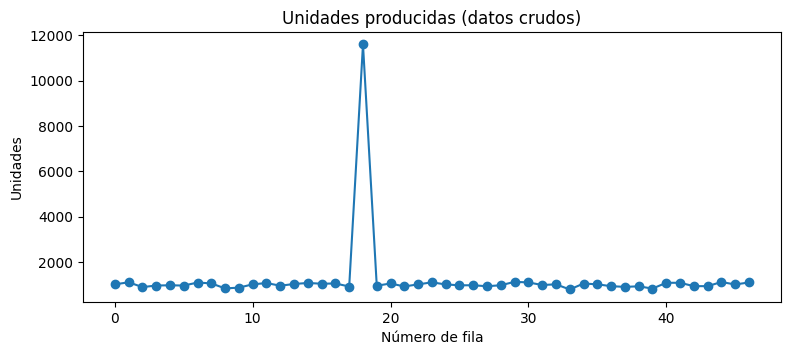

In [17]:
df["unidades_producidas"].plot(figsize=(9, 3.5), marker="o")
plt.title("Unidades producidas (datos crudos)")
plt.xlabel("Número de fila")
plt.ylabel("Unidades")
plt.show()

### 5.2 Gráfico de barras: filas por máquina

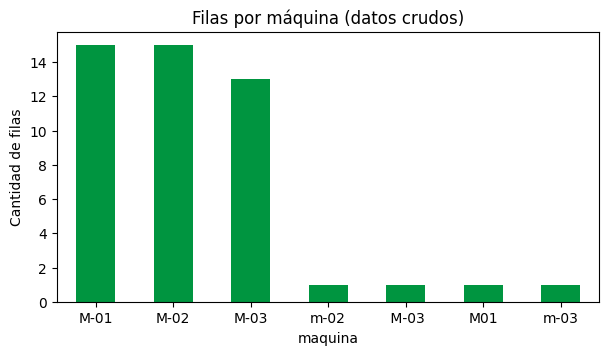

In [18]:
df["maquina"].value_counts().plot(kind="bar", figsize=(7, 3.5), color="#009540")
plt.title("Filas por máquina (datos crudos)")
plt.ylabel("Cantidad de filas")
plt.xticks(rotation=0)
plt.show()

> 👀 ¿Ves **M-03 dos veces**? No es un error del gráfico: una de ellas es `" M-03"`, con un **espacio invisible** al inicio. Para la computadora son textos distintos.

### 5.3 Histograma: ¿cómo se distribuye la temperatura?

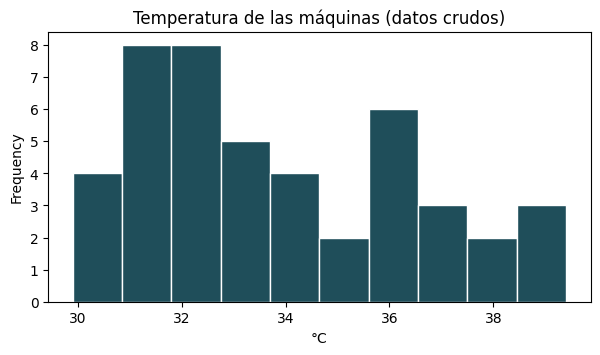

In [19]:
df["temperatura_c"].plot(kind="hist", bins=10, figsize=(7, 3.5), color="#1F4E5A", edgecolor="white")
plt.title("Temperatura de las máquinas (datos crudos)")
plt.xlabel("°C")
plt.show()

🧠 **Responde:** los gráficos acaban de delatar los problemas de calidad. Escribe **qué problema** revela cada uno:
1. El gráfico de líneas: Muestra un **pico enorme** en una de las filas (unidades_producidas = 11.600), muy por encima del resto de la serie, que ronda entre 800 y 1.130. Es un error de digitación evidente a simple vista.
2. El gráfico de barras: En vez de 3 barras (una por máquina) aparecen **7 barras**, porque el nombre de la máquina está escrito de varias formas (`M-03`, `m-03`, ` M-03`, `M01`, etc.) y pandas las cuenta como máquinas distintas.
3. `info()` (Parte 4), en la columna `temperatura_c`: Tiene **menos valores no nulos que el total de filas** (45 de 47), es decir, le **faltan 2 datos** (celdas vacías) que no se ven en el gráfico de líneas ni de barras, pero sí en el conteo de `info()`.

*Tu respuesta:* (completado arriba, punto por punto)

> Esta es la "V" de **veracidad** que vimos en la semana 2: si analizamos estos datos sin limpiarlos, las conclusiones salen mal ("basura entra, basura sale").


## Parte 6 · Limpieza mínima
Vamos a corregir **cuatro** problemas, uno por celda. Trabajamos sobre una **copia** para no dañar los datos originales y poder comparar el antes y el después.

In [20]:
limpio = df.copy()                  # copia independiente de los datos originales
print("Filas al empezar:", len(limpio))

Filas al empezar: 47


### 6.1 Homologar los códigos de máquina
`" M-03"`, `"m-03"` y `"M03"` son la misma máquina escrita de tres formas. Usamos los métodos de texto de la Parte 1, aplicados a **toda la columna** con `.str`:

In [21]:
limpio["maquina"] = (limpio["maquina"]
                     .str.strip()                                   # quita espacios
                     .str.upper()                                   # a MAYÚSCULAS
                     .str.replace("M0", "M-0", regex=False))        # "M01" -> "M-01"
limpio["maquina"].value_counts()

,count
maquina,
M-01,16
M-02,16
M-03,15


### 6.2 Quitar filas repetidas

In [22]:
print("Filas repetidas:", limpio.duplicated().sum())
limpio = limpio.drop_duplicates()
print("Filas ahora:", len(limpio))

Filas repetidas: 2
Filas ahora: 45


### 6.3 Valores vacíos (nulos)
`isna()` marca las celdas vacías y `.sum()` las cuenta por columna. Para la temperatura tenemos dos opciones: **eliminar** la fila o **rellenar** el vacío. Aquí rellenamos con la **mediana** de la temperatura de **esa misma máquina**, porque la producción de ese día sí es válida y no queremos perderla.

In [23]:
print("Vacíos por columna ANTES:\n", limpio.isna().sum(), "\n")

mediana_por_maquina = limpio.groupby("maquina")["temperatura_c"].transform("median")
limpio["temperatura_c"] = limpio["temperatura_c"].fillna(mediana_por_maquina)

print("Vacíos por columna DESPUÉS:\n", limpio.isna().sum())

Vacíos por columna ANTES:
 fecha                   0
maquina                 0
unidades_producidas     0
unidades_defectuosas    0
temperatura_c           2
dtype: int64 

Vacíos por columna DESPUÉS:
 fecha                   0
maquina                 0
unidades_producidas     0
unidades_defectuosas    0
temperatura_c           0
dtype: int64


### 6.4 Un valor imposible
Una máquina produce alrededor de 1.000 unidades al día. El valor de **más de 10.000** es un error de digitación (un cero de más). Como no sabemos con certeza el valor real, **retiramos esa fila** y lo dejamos anotado.

In [24]:
print("Fila sospechosa:")
print(limpio[limpio["unidades_producidas"] > 5000])

limpio = limpio[limpio["unidades_producidas"] <= 5000]
print("\nFilas al terminar la limpieza:", len(limpio))

Fila sospechosa:
         fecha maquina  unidades_producidas  unidades_defectuosas  \
18  2026-09-07    M-01                11600                    31   

    temperatura_c  
18           33.0  

Filas al terminar la limpieza: 44


### 6.5 Fechas como fechas
La columna `fecha` se cargó como **texto**. La convertimos a tipo fecha para que los gráficos la ordenen como calendario.

In [25]:
limpio["fecha"] = pd.to_datetime(limpio["fecha"])
limpio.dtypes

,0
fecha,datetime64[ns]
maquina,object
unidades_producidas,int64
unidades_defectuosas,int64
temperatura_c,float64


**Resumen del antes y el después:**

| Problema | Antes | Después |
|---|---|---|
| Filas | 47 | 44 |
| Nombres de máquina distintos | 7 | 3 |
| Filas repetidas | 2 | 0 |
| Temperaturas vacías | 2 | 0 |
| Valores imposibles | 1 | 0 |

## Parte 7 · Graficar de nuevo y comparar
Ponemos lado a lado el **antes** y el **después**. `plt.subplots(1, 2)` crea una figura con dos gráficos en una fila.

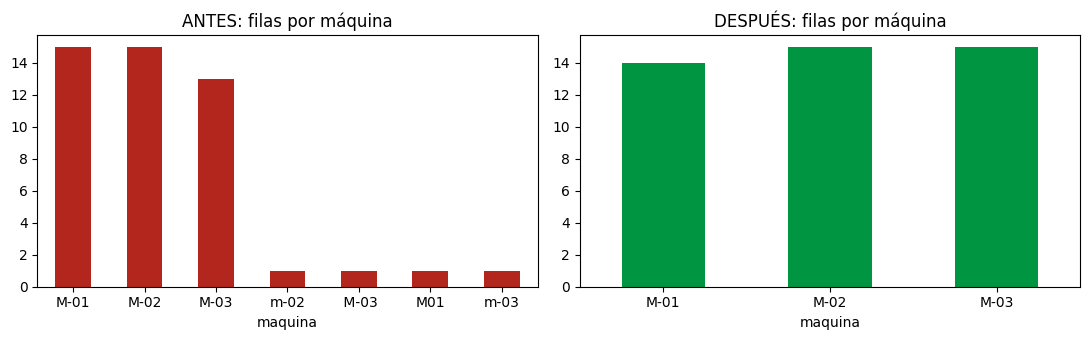

In [26]:
fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 3.5))

df["maquina"].value_counts().plot(kind="bar", ax=izq, color="#B3261E")
izq.set_title("ANTES: filas por máquina")
izq.tick_params(axis="x", rotation=0)

limpio["maquina"].value_counts().sort_index().plot(kind="bar", ax=der, color="#009540")
der.set_title("DESPUÉS: filas por máquina")
der.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Ahora sí, un gráfico que responde una pregunta: ¿cómo produjo cada máquina día a día?

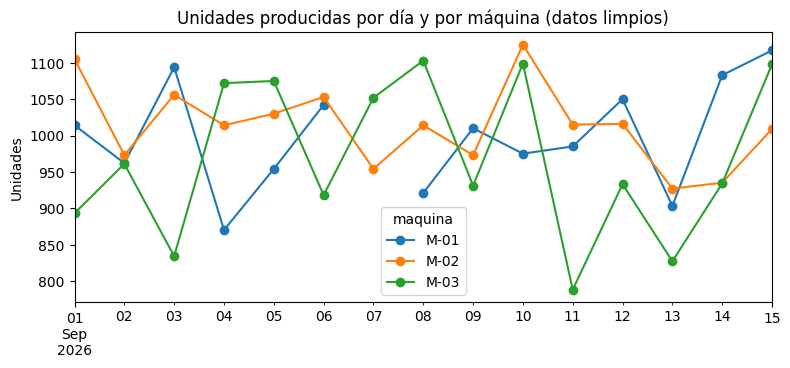

In [27]:
por_dia = limpio.pivot_table(index="fecha", columns="maquina", values="unidades_producidas")
por_dia.plot(figsize=(9, 3.5), marker="o")
plt.title("Unidades producidas por día y por máquina (datos limpios)")
plt.ylabel("Unidades")
plt.xlabel("")
plt.show()

> `pivot_table` **reorganiza** la tabla: pone las fechas en las filas y una columna por máquina. Así pandas dibuja una línea por máquina.

🧠 **Responde:** ¿por qué la línea de **M-01** se interrumpe el **7 de septiembre**? (Pista: Parte 6.4.) ¿Es mejor un hueco honesto que un dato inventado?

*Tu respuesta:* Se interrumpe porque en la Parte 6.4 eliminamos la fila de M-01 del 7 de septiembre (el valor imposible de 11.600 unidades). Al no tener un dato confiable para ese día, no lo reemplazamos por ningún número: preferimos dejar el hueco. Sí, un **hueco honesto es mejor que un dato inventado**, porque no sabemos cuál fue la producción real ese día; rellenarlo con un promedio o una cifra cualquiera generaría una conclusión falsa, mientras que el hueco deja claro que ahí falta información.


## Parte 8 · Tu primera respuesta con datos
¿Qué máquina tiene **más defectos**? Calculamos el porcentaje de unidades defectuosas y lo **agrupamos por máquina** con `groupby`.

In [28]:
limpio["pct_defectos"] = limpio["unidades_defectuosas"] / limpio["unidades_producidas"] * 100

resumen = limpio.groupby("maquina")[["pct_defectos", "temperatura_c"]].mean().round(2)
resumen

,pct_defectos,temperatura_c
maquina,,
M-01,1.92,33.06
M-02,1.17,31.49
M-03,5.82,37.13


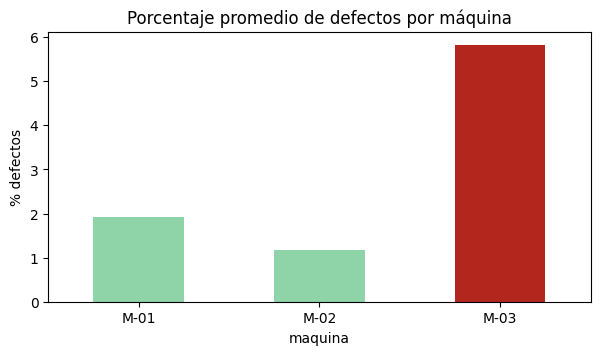

In [29]:
resumen["pct_defectos"].plot(kind="bar", figsize=(7, 3.5), color=["#8FD3A8", "#8FD3A8", "#B3261E"])
plt.title("Porcentaje promedio de defectos por máquina")
plt.ylabel("% defectos")
plt.xticks(rotation=0)
plt.show()

🧠 **Responde:**
1. ¿Qué máquina tiene más defectos? ¿Es también la de mayor temperatura promedio?
2. Recuerda la semana 1: ¿esto demuestra que la temperatura **causa** los defectos? ¿Qué más revisarías?
3. Si **no** hubieras limpiado los datos, ¿qué habría salido mal en esta tabla?

*Tu respuesta:*
1. **M-03** tiene el mayor porcentaje de defectos (≈5,82 %), muy por encima de M-01 (≈1,92 %) y M-02 (≈1,17 %). Y sí, M-03 también tiene la **temperatura promedio más alta** (≈37,1 °C, frente a ≈33,1 °C de M-01 y ≈31,5 °C de M-02).
2. No, esto **no demuestra causalidad**: que las dos variables suban juntas solo indica una **correlación**. Podría haber otra causa detrás de ambas (por ejemplo, la máquina M-03 es más antigua, tiene un desgaste mecánico, o procesa un material distinto que la calienta más y a la vez produce más defectos). Para acercarme a una causa revisaría el mantenimiento de cada máquina, la antigüedad, el tipo de producto que procesa y si el defecto ocurre justo cuando sube la temperatura dentro del mismo día.
3. Sin limpiar los datos, el `groupby` habría tratado `M-03`, `m-03`, ` M-03` y `M01` (para M-01) como máquinas **distintas**, dividiendo mal los promedios entre "7 máquinas" en vez de 3; la fila repetida habría inflado el promedio de esa máquina; el valor de 11.600 unidades habría disparado el promedio de M-01; y las 2 temperaturas vacías habrían quedado como huecos o habrían dañado el cálculo del promedio. En resumen: la tabla final habría dado **conclusiones equivocadas** sobre qué máquina falla más.


## Parte 9 · Guardar el resultado
Guardamos los datos limpios en un nuevo CSV. Así el trabajo queda listo para el siguiente paso (por ejemplo, un tablero en Power BI).

In [30]:
limpio.to_csv("produccion_septiembre_limpio.csv", index=False)   # index=False: no guardar el índice
print("Guardado: produccion_septiembre_limpio.csv ·", len(limpio), "filas")

Guardado: produccion_septiembre_limpio.csv · 44 filas


## ✅ Resumen: lo que usaste hoy

| Quiero… | Código |
|---|---|
| Traer una librería | `import pandas as pd` |
| Cargar un CSV | `pd.read_csv("archivo.csv")` |
| Ver las primeras / últimas filas | `df.head()` · `df.tail()` |
| Tamaño y tipos | `df.shape` · `df.info()` |
| Estadísticas | `df.describe()` |
| Contar valores de una columna | `df["col"].value_counts()` |
| Filtrar filas | `df[df["col"] > 100]` |
| Graficar | `.plot()` · `.plot(kind="bar")` · `.plot(kind="hist")` |
| Limpiar texto | `.str.strip()` · `.str.upper()` · `.str.replace()` |
| Quitar repetidas | `df.drop_duplicates()` |
| Contar y rellenar vacíos | `df.isna().sum()` · `.fillna(valor)` |
| Agrupar y promediar | `df.groupby("col")["otra"].mean()` |
| Guardar | `df.to_csv("nuevo.csv", index=False)` |

**Entrega:** descarga este cuaderno (en Colab: *Archivo → Descargar → .ipynb*; en VS Code ya es un archivo) y súbelo a tu fork en `08-week/01-session/`.

**Próxima clase:** con estas mismas herramientas armaremos un **pipeline ETL completo**: tres fuentes (CSV, JSON y una API real), limpieza a fondo, una base de datos SQL y una decisión de mantenimiento.